In [1]:
import coolbox
from coolbox.api import *
from glob import glob

import numpy as np
import pandas as pd

In [2]:
new_regions = {"Cd4 Tfh arch": "peak.44888",
    "Cd4 Treg arch": "peak.44902",
    "Cd8 dys arch": "peak.44926",
    "T cell activation arch": "peak.44945"}

In [3]:
peak_info = pd.read_csv("/Genomics/pritykinlab/sarah/bulk_cd4_peak_atlas/peaks.more_info.bed", sep = "\t",
                        header = None)

In [4]:
def name(df):
    return "%s:%s-%s"%(df[0].values[0], df[1].values[0], df[2].values[0])
new_regions_2 = {p: name(peak_info[peak_info[3] == new_regions[p]]) for p in new_regions.keys()}

In [5]:
bws = ["bigwig_stuff/Cd4_Tfh.bw", "bigwig_stuff/Cd8_dys.bw", "bigwig_stuff/Cd4_Treg.bw", "bigwig_stuff/Cd8_eff.bw",
       "bigwig_stuff/Cd8_prog.bw"]
bws

['bigwig_stuff/Cd4_Tfh.bw',
 'bigwig_stuff/Cd8_dys.bw',
 'bigwig_stuff/Cd4_Treg.bw',
 'bigwig_stuff/Cd8_eff.bw',
 'bigwig_stuff/Cd8_prog.bw']

In [6]:
gtf_file = "/Genomics/pritykinlab/sarah/sarah-scripts/atac/sorted.gencode.vM25.annotation.gtf"

In [7]:
import scanpy as sc
sc.set_figure_params(figsize = (5,5))

In [8]:
def make_small_plot(min_, max_, bigwig_fns, loc = "1:164055000-164100000", style = "flybase", 
                  save = None, highlight_region = None):
    
    with HighLights([highlight_region], color = "lightgray", border_line = False):
        frame2 = BigWig(str(bigwig_fns[
            0]), min_value = min_, max_value = max_) + Title(str(bigwig_fns[0]).split("/")[-1].split(".")[0]) + Color(
            "#bd6960") + BigWig(str(bigwig_fns[1]), min_value = min_, max_value = max_) + Title(
            str(bigwig_fns[1]).split("/")[-1].split(".")[0]) + Color('#84cdee') + \
        BigWig(str(bigwig_fns[2]), min_value = min_, max_value = max_) + Title(str(bigwig_fns[2]).split("/")[
            -1].split(".")[0])  + Color('#0039d6')  + \
        BigWig(str(bigwig_fns[3]), min_value = min_, max_value = max_) + Title(str(bigwig_fns[3]).split("/")[
            -1].split(".")[0]) + Color("#ba9362") + \
        BigWig(str(bigwig_fns[4]), min_value = min_, max_value = max_) + Title(str(bigwig_fns[4]).split("/")[
            -1].split(".")[0]) + Color('#abbadf') + XAxis()
    frame = frame2 + BED("bigwig_stuff/gene_annotations/sorted.m_v25_final.bed",  gene_style=style) + BED(
    "../new_bigwigs_mar2025/peak_atlas.bed")
    if save is None:
        return frame.plot(loc) # , dpi = 200) 
    else:
        bsr = Browser(frame, init_range = loc)
        bsr.save(save, dpi = 200)
        

In [9]:
## this one works I think?
#        
#    
colors = {'Cd4 Tfh': '#ba9362',
 'Cd4 Th1': '#bd6960',
 'Cd4 Th2': '#7f180f',
 'Cd4 Treg': '#e7ad36',
 'Cd4 mem': '#fc6121',
 'Cd4 naïve': '#d53724',
 'Cd8 dys': '#0039d6',
 'Cd8 eff': '#84cdee',
 'Cd8 mem': '#76ad83',
 'Cd8 naïve': '#008a7d',
 'Cd8 prog': '#abbadf',
 'Other': '#818181'}

arch_colors = {"Cd8 naive arch": "#3E7958",
               "Cd8 mem arch": "#A4CCB4",
               "Cd4 Tfh arch": "#C4AF9A",
               "Cd8 dys arch": "#2B3A67",
               "Cd4 Th1 arch": "#D58696",
               "T cell activation arch": "#D58696",
               "Cd8 eff arch": "#73ACBF",
               "Cd4 Treg arch": "#FFDE70",
               "Cd4 naive-mem arch": "#C85919"}


def tox_full_plot(min_, max_, bigwig_fns, loc = "1:164055000-164100000", style = "flybase", 
                  save = None):
    # 
    highlights =  HighLights(list(new_regions_2.values()), border_line = False) 
    #+ HighLights([
    #    regions[keys[1]]], color = arch_colors[keys[1]], border_line = False) + HighLights([regions[keys[
    #    2]]], color = arch_colors[keys[2]], border_line = False)
    
    with highlights:
        frame1 = BigWig(str(bigwig_fns[0]), min_value = min_, max_value = max_) + Title(str(bigwig_fns[0]).split(
            "/")[-1].split(".")[0]) + Color(colors["Cd4 Tfh"]) + BigWig(str(bigwig_fns[
            1]), min_value = min_, max_value = max_) + Title(str(bigwig_fns[1]).split("/")[-1].split(".")[0]) + \
        Color(colors["Cd8 dys"]) + BigWig(str(bigwig_fns[2]), min_value = min_, max_value = max_) + Title(str(
            bigwig_fns[2]).split("/")[-1].split(".")[0])  + Color(colors["Cd4 Treg"])  + BigWig(str(bigwig_fns[
            3]), min_value = min_, max_value = max_) + Title(str(bigwig_fns[3]).split("/")[-1].split(".")[0]) + \
        Color(colors["Cd4 Th1"]) + BigWig(str(bigwig_fns[4]), min_value = min_, max_value = max_) + Title(str(
            bigwig_fns[4]).split("/")[-1].split(".")[0]) + Color(colors["Cd8 eff"]) + BigWig(str(bigwig_fns[
            4]), min_value = min_, max_value = max_) + Title(str(bigwig_fns[4]).split("/")[-1].split(".")[0]) + \
        Color(colors["Cd8 prog"]) + XAxis()
    beds = BED("bigwig_stuff/tox_peaks.Cd4_Treg_arch.bed", display='collapsed', color = "#FFDE70", 
               border_color =  "#FFDE70", labels = False) + Title("Cd4 Treg arch") + TrackHeight(0.6) + BED(
    #    "bigwig_stuff/tox_peaks.%s.bed"%"Cd8_eff_arch", display='collapsed') + \
    #Color("#73ACBF") + Title("Cd8 eff arch") + BED(
        "bigwig_stuff/tox_peaks.%s.bed"%"T_cell_activation_arch", display='collapsed', color = "#D58696", 
        border_color = "#D58696", labels = False) + Title("T cell activation arch") + TrackHeight(0.6) + BED(
        "bigwig_stuff/tox_peaks.%s.bed"%"Cd8_dys_arch", display='collapsed', color = "#2B3A67", 
        border_color = "#2B3A67", labels = False) + Title("Cd8 dys arch") + TrackHeight(0.6) + BED(
        "bigwig_stuff/tox_peaks.%s.bed"%"Cd4_Tfh_arch", display='collapsed', color = "#C4AF9A", 
        border_color = "#C4AF9A", labels = False) + Title("Cd4 Tfh arch") + TrackHeight(0.6)
    # frame1 = frame1 * Vlines(vlines = [("chr1", 18250448), ("chr1", 18250597)], line_width=2)
    frame = frame1 + BED("bigwig_stuff/gene_annotations/sorted.m_v25_final.bed",  gene_style=style) + beds
#     if regions is not None:
 #       frame = frame1 + frame2 + BED("bigwig_stuff/gene_annotations/sorted.m_v25_final.bed", 
 #                                     gene_style=style) + beds
    if save is None:
        return frame.plot(loc) # , dpi = 200) 
    else:
        bsr = Browser(frame, init_range = loc)
        bsr.save(save, dpi = 200)
        
        

        

In [10]:
## this one works I think?
#        
#    

arch_colors = {"Cd8 naive arch": "#3E7958",
               "Cd8 mem arch": "#A4CCB4",
               "Cd4 Tfh arch": "#C4AF9A",
               "Cd8 dys arch": "#2B3A67",
               "Cd4 Th1 arch": "#D58696",
               "T cell activation arch": "#D58696",
               "Cd8 eff arch": "#73ACBF",
               "Cd4 Treg arch": "#FFDE70",
               "Cd4 naive-mem arch": "#C85919"}


def old_make_plot(min_, max_, bigwig_fns, loc = "1:164055000-164100000", style = "flybase", 
                  save = None, regions = None):
    # 
#     highlights =  HighLights([regions[first]], color = arch_colors[first], border_line = False)
# + HighLights([regions[keys[
        # 3]]], color = arch_colors[keys[3]], border_line = False) 
    print(highlights)
    if regions is not None:
        keys = list(regions.keys())
        frame1 = HighLights([regions[keys[0]]], color = arch_colors[keys[0]], border_line = False) + HighLights(
            [regions[keys[1]]], color = arch_colors[keys[1]], border_line = False) +  HighLights([regions[keys[
            2]]], color = arch_colors[keys[2]], border_line = False)
    frame2 = BigWig(str(bigwig_fns[
        0]), min_value = min_, max_value = max_) + Title(str(bigwig_fns[0]).split("/")[-1].split(".")[0]) + Color(
        "#bd6960") + BigWig(str(bigwig_fns[1]), min_value = min_, max_value = max_) + Title(
        str(bigwig_fns[1]).split("/")[-1].split(".")[0]) + Color('#84cdee') + \
    BigWig(str(bigwig_fns[2]), min_value = min_, max_value = max_) + Title(str(bigwig_fns[2]).split("/")[
        -1].split(".")[0])  + Color('#0039d6')  + \
    BigWig(str(bigwig_fns[3]), min_value = min_, max_value = max_) + Title(str(bigwig_fns[3]).split("/")[
        -1].split(".")[0]) + Color("#ba9362") + \
    BigWig(str(bigwig_fns[4]), min_value = min_, max_value = max_) + Title(str(bigwig_fns[4]).split("/")[
        -1].split(".")[0]) + Color('#abbadf') + XAxis()
    beds = BED("bigwig_stuff/tox_peaks.Cd4_Treg_arch.bed", display='collapsed', color = "#FFDE70", 
               border_color =  "#FFDE70", labels = False) + Title("Cd4 Treg arch") + TrackHeight(0.6) + BED(
    #    "bigwig_stuff/tox_peaks.%s.bed"%"Cd8_eff_arch", display='collapsed') + \
    #Color("#73ACBF") + Title("Cd8 eff arch") + BED(
        "bigwig_stuff/tox_peaks.%s.bed"%"T_cell_activation_arch", display='collapsed', color = "#D58696", 
        border_color = "#D58696", labels = False) + Title("T cell activation arch") + TrackHeight(0.6) + BED(
        "bigwig_stuff/tox_peaks.%s.bed"%"Cd8_dys_arch", display='collapsed', color = "#2B3A67", 
        border_color = "#2B3A67", labels = False) + Title("Cd8 dys arch") + TrackHeight(0.6) + BED(
        "bigwig_stuff/tox_peaks.%s.bed"%"Cd4_Tfh_arch", display='collapsed', color = "#C4AF9A", 
        border_color = "#C4AF9A", labels = False) + Title("Cd4 Tfh arch") + TrackHeight(0.6) + BED(
        "bigwig_stuff/tox_peaks.%s.bed"%"Cd8_mem_arch", display='collapsed', color = "#A4CCB4", 
        border_color = "#A4CCB4", labels = False) + Title("Cd8 mem arch") + TrackHeight(0.6) + BED(
        "bigwig_stuff/tox_peaks.%s.bed"%"Cd8_naive_arch", display='collapsed', color = "#3E7958", 
        border_color = "#3E7958", labels = False) + Title("Cd8 naive arch") + TrackHeight(0.6)+ BED(
        "bigwig_stuff/tox_peaks.%s.bed"%"Cd4_naive-mem_arch", display='collapsed', color = "#C85919", 
        border_color = "#C85919", labels = False) + Title("Cd4 naive-mem arch") + TrackHeight(0.6)
    # frame1 = frame1 * Vlines(vlines = [("chr1", 18250448), ("chr1", 18250597)], line_width=2)
    frame = frame2 + BED("bigwig_stuff/gene_annotations/sorted.m_v25_final.bed",  gene_style=style) + beds + BED(
    "../new_bigwigs_mar2025/peak_atlas.bed")
    if regions is not None:
        frame = frame1 + frame2 + BED("bigwig_stuff/gene_annotations/sorted.m_v25_final.bed", 
                                      gene_style=style) + beds
    if save is None:
        return frame.plot(loc) # , dpi = 200) 
    else:
        bsr = Browser(frame, init_range = loc)
        bsr.save(save, dpi = 200)
        
        
        
        

In [11]:
good_peaks = {"Cd4 Treg arch": "4:6811706-6812404", "Cd8 dys arch": "4:6843405-6844859", 
              "Cd4 Tfh arch": "4:6880568-6881920"}

highlight_peaks = {"Cd4 Treg arch": "4:6747734-6748882",
                  "Cd8 dys arch": "4:6834261-6834953",
                  "T cell activation arch": "4:6884144-6884486",
                  "Cd4 Tfh arch": "4:6968879-6969149"}

In [12]:
new_bws = glob("../new_bigwigs_mar2025/final*bw")
new_bws

['../new_bigwigs_mar2025/final_normalized_Cd4_th1.bw',
 '../new_bigwigs_mar2025/final_normalized_Cd8_eff.bw',
 '../new_bigwigs_mar2025/final_normalized_Cd8_dys.bw',
 '../new_bigwigs_mar2025/final_normalized_Cd4_tfh.bw',
 '../new_bigwigs_mar2025/final_normalized_Cd8_prog.bw']

## main figure 3 C tracks

[WARNING:plot.py:58 -           plot_genes()] *WARNING* Color set to 'bed_rgb', but bed file does not have the rgb field. The color has been set to #1f78b4
[WARNING:plot.py:166 -           plot_genes()] *Warning* No intervals were found for file bigwig_stuff/gene_annotations/sorted.m_v25_final.bed in Track 'BED.28' for the interval plotted (16:23962000-23963800).

[WARNING:bed.py:291 -     get_bed_interval()] *Warning, invalid strand value found 1137 for line #16	23962195	23963332	*	peak.187386	1137
:
1
 Setting strand to '.'

[WARNING:plot.py:58 -           plot_genes()] *WARNING* Color set to 'bed_rgb', but bed file does not have the rgb field. The color has been set to #1f78b4


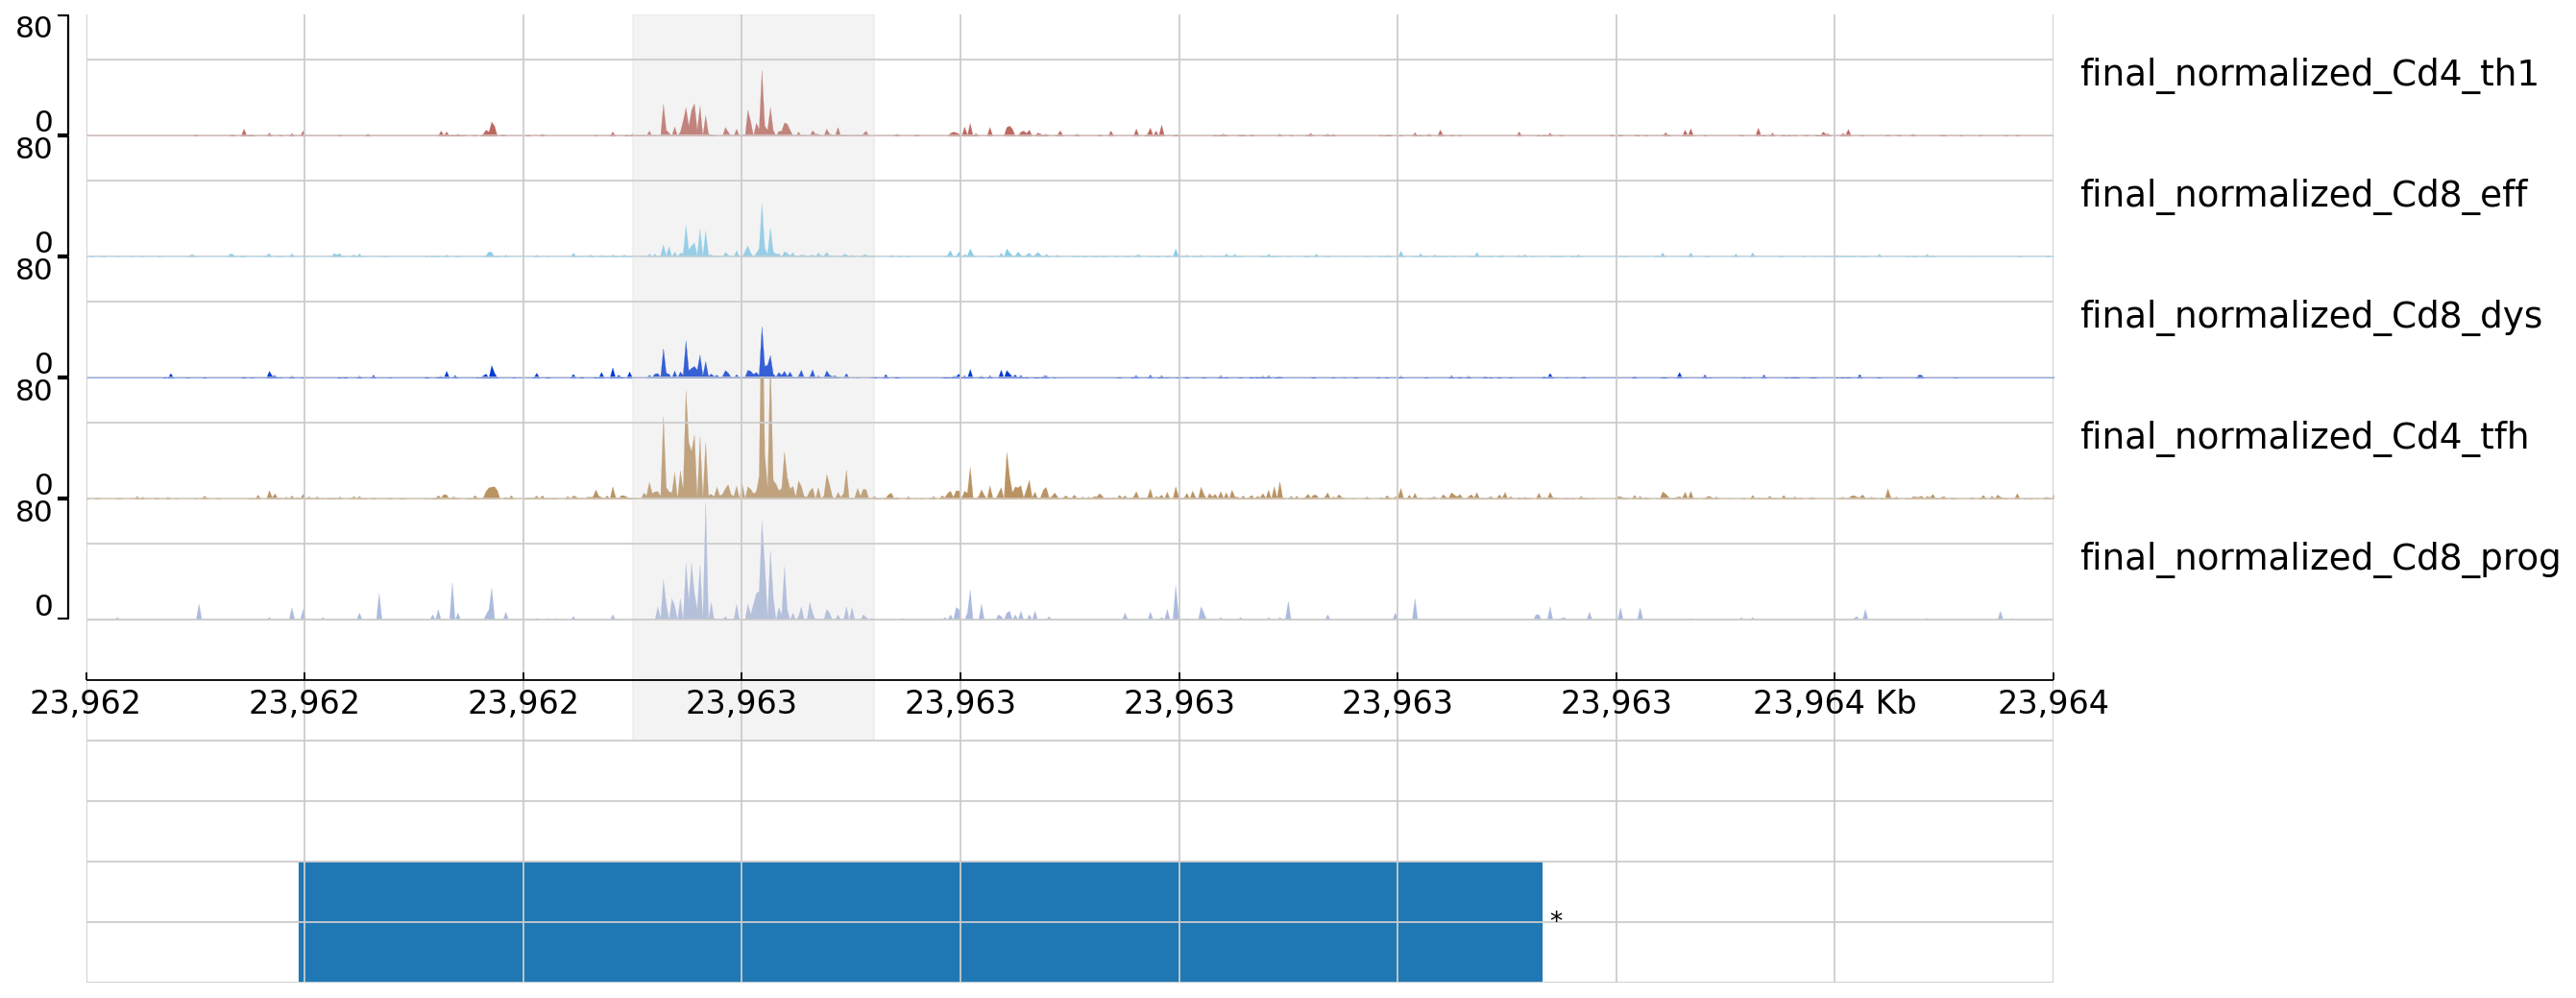

In [24]:
## just to get a sense of what they look like
make_small_plot(0, 80, new_bws, loc = "chr16:23962000-23963800", style = "flybase",  highlight_region = 
                "chr16:23962500-23962720")

In [13]:
make_small_plot(0, 80, new_bws, loc = "chr16:23962000-23963800", style = "flybase",  highlight_region = 
                "chr16:23962500-23962720", save = "../new_bigwigs_mar2025/plots/bcl6_small_track.downstream.pdf")

[WARNING:plot.py:58 -           plot_genes()] *WARNING* Color set to 'bed_rgb', but bed file does not have the rgb field. The color has been set to #1f78b4
[WARNING:plot.py:166 -           plot_genes()] *Warning* No intervals were found for file bigwig_stuff/gene_annotations/sorted.m_v25_final.bed in Track 'BED.1' for the interval plotted (16:23961999-23963800).

[WARNING:bed.py:291 -     get_bed_interval()] *Warning, invalid strand value found 1137 for line #16	23962195	23963332	*	peak.187386	1137
:
1
 Setting strand to '.'

[WARNING:plot.py:58 -           plot_genes()] *WARNING* Color set to 'bed_rgb', but bed file does not have the rgb field. The color has been set to #1f78b4


[WARNING:bed.py:291 -     get_bed_interval()] *Warning, invalid strand value found 1407 for line #9	44526056	44527463	*	peak.110120	1407
:
1
 Setting strand to '.'

[WARNING:bed.py:291 -     get_bed_interval()] *Warning, invalid strand value found 837 for line #9	44528142	44528979	*	peak.110121	837
:
2
 Setting strand to '.'

[WARNING:bed.py:291 -     get_bed_interval()] *Warning, invalid strand value found 142 for line #9	44529104	44529246	*	peak.110122	142
:
3
 Setting strand to '.'

[WARNING:bed.py:291 -     get_bed_interval()] *Warning, invalid strand value found 131 for line #9	44529496	44529627	*	peak.110123	131
:
4
 Setting strand to '.'

[WARNING:plot.py:58 -           plot_genes()] *WARNING* Color set to 'bed_rgb', but bed file does not have the rgb field. The color has been set to #1f78b4


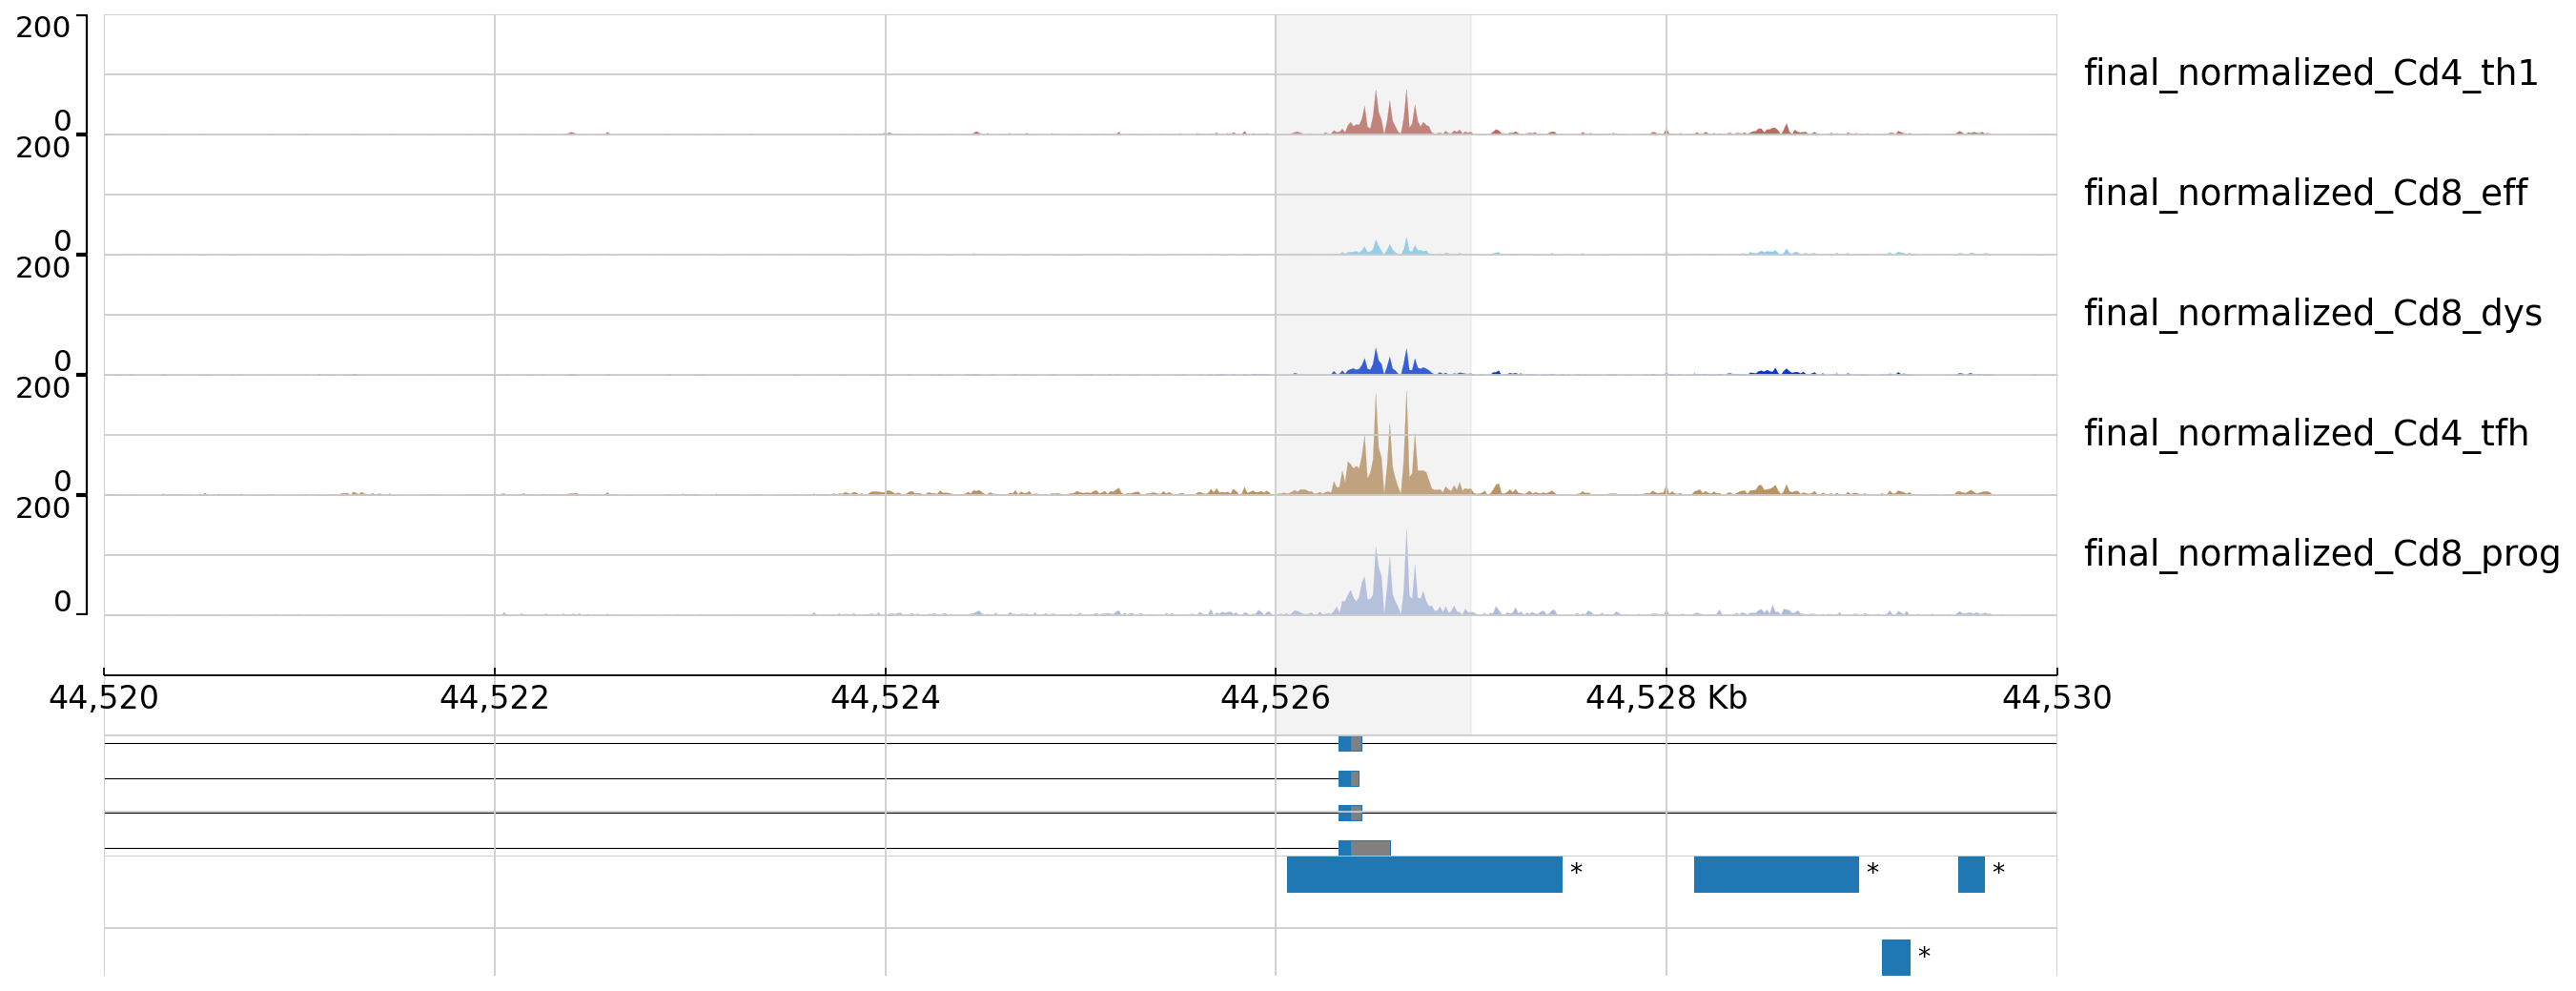

In [19]:
make_small_plot(min_ = 0, max_ = 200, bigwig_fns = new_bws, loc = "chr9:44520000-44530000", highlight_region = 
                "chr9:44526000-44527000")

In [14]:
make_small_plot(min_ = 0, max_ = 200, bigwig_fns = new_bws, loc = "chr9:44520000-44530000", highlight_region = 
                "chr9:44526000-44527000", save = "../new_bigwigs_mar2025/plots/cxcr5_small_track.pdf")


[WARNING:bed.py:291 -     get_bed_interval()] *Warning, invalid strand value found 1407 for line #9	44526056	44527463	*	peak.110120	1407
:
1
 Setting strand to '.'

[WARNING:bed.py:291 -     get_bed_interval()] *Warning, invalid strand value found 837 for line #9	44528142	44528979	*	peak.110121	837
:
2
 Setting strand to '.'

[WARNING:bed.py:291 -     get_bed_interval()] *Warning, invalid strand value found 142 for line #9	44529104	44529246	*	peak.110122	142
:
3
 Setting strand to '.'

[WARNING:bed.py:291 -     get_bed_interval()] *Warning, invalid strand value found 131 for line #9	44529496	44529627	*	peak.110123	131
:
4
 Setting strand to '.'

[WARNING:plot.py:58 -           plot_genes()] *WARNING* Color set to 'bed_rgb', but bed file does not have the rgb field. The color has been set to #1f78b4


[WARNING:plot.py:58 -           plot_genes()] *WARNING* Color set to 'bed_rgb', but bed file does not have the rgb field. The color has been set to #1f78b4
[WARNING:plot.py:166 -           plot_genes()] *Warning* No intervals were found for file bigwig_stuff/gene_annotations/sorted.m_v25_final.bed in Track 'BED.20' for the interval plotted (4:6670000-6677000).

[WARNING:bed.py:291 -     get_bed_interval()] *Warning, invalid strand value found 935 for line #4	6674841	6675776	*	peak.44888	935
:
1
 Setting strand to '.'

[WARNING:plot.py:58 -           plot_genes()] *WARNING* Color set to 'bed_rgb', but bed file does not have the rgb field. The color has been set to #1f78b4


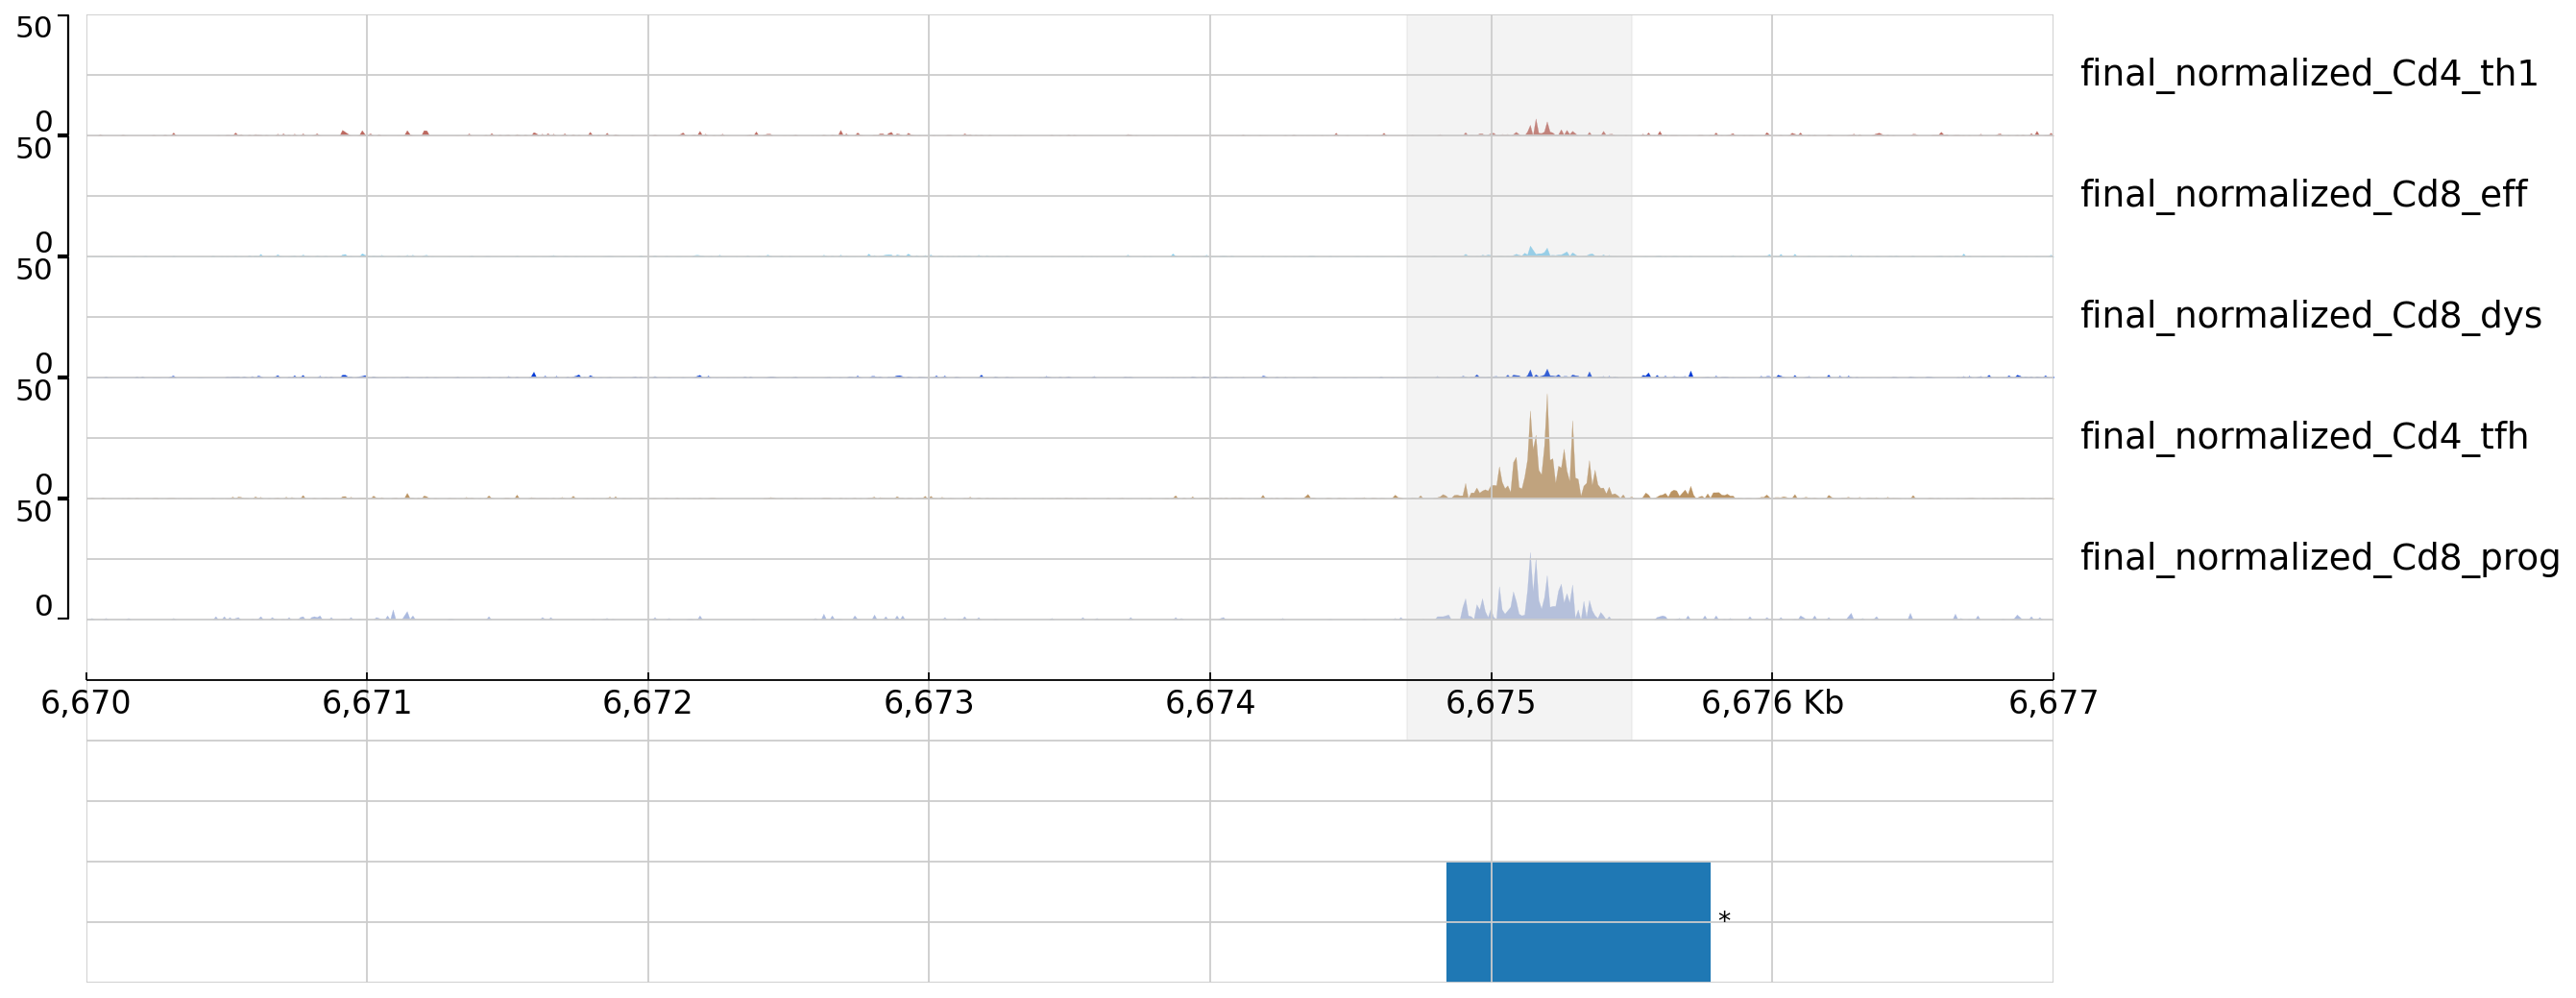

In [20]:
make_small_plot(min_ = 0, max_ = 50, bigwig_fns = new_bws, loc = "chr4:6670000-6677000", highlight_region = 
                "chr4:6674700-6675500")

In [15]:
make_small_plot(min_ = 0, max_ = 50, bigwig_fns = new_bws, loc = "chr4:6670000-6677000", highlight_region = 
                "chr4:6674700-6675500", save = "../new_bigwigs_mar2025/plots/tox_small_track.pdf")


[WARNING:plot.py:58 -           plot_genes()] *WARNING* Color set to 'bed_rgb', but bed file does not have the rgb field. The color has been set to #1f78b4
[WARNING:plot.py:166 -           plot_genes()] *Warning* No intervals were found for file bigwig_stuff/gene_annotations/sorted.m_v25_final.bed in Track 'BED.5' for the interval plotted (4:6669999-6677000).

[WARNING:bed.py:291 -     get_bed_interval()] *Warning, invalid strand value found 935 for line #4	6674841	6675776	*	peak.44888	935
:
1
 Setting strand to '.'

[WARNING:plot.py:58 -           plot_genes()] *WARNING* Color set to 'bed_rgb', but bed file does not have the rgb field. The color has been set to #1f78b4


In [16]:
treg_bws = glob("../new_bigwigs_mar2025/treg_final*bw")
treg_bws

['../new_bigwigs_mar2025/treg_final_normalized_Cd4_tfh.bw',
 '../new_bigwigs_mar2025/treg_final_normalized_Cd8_dys.bw',
 '../new_bigwigs_mar2025/treg_final_normalized_Cd4_Treg.bw',
 '../new_bigwigs_mar2025/treg_final_normalized_Cd4_th1.bw',
 '../new_bigwigs_mar2025/treg_final_normalized_Cd8_eff.bw',
 '../new_bigwigs_mar2025/treg_final_normalized_Cd8_prog.bw']

## Tox track for supplemental figure

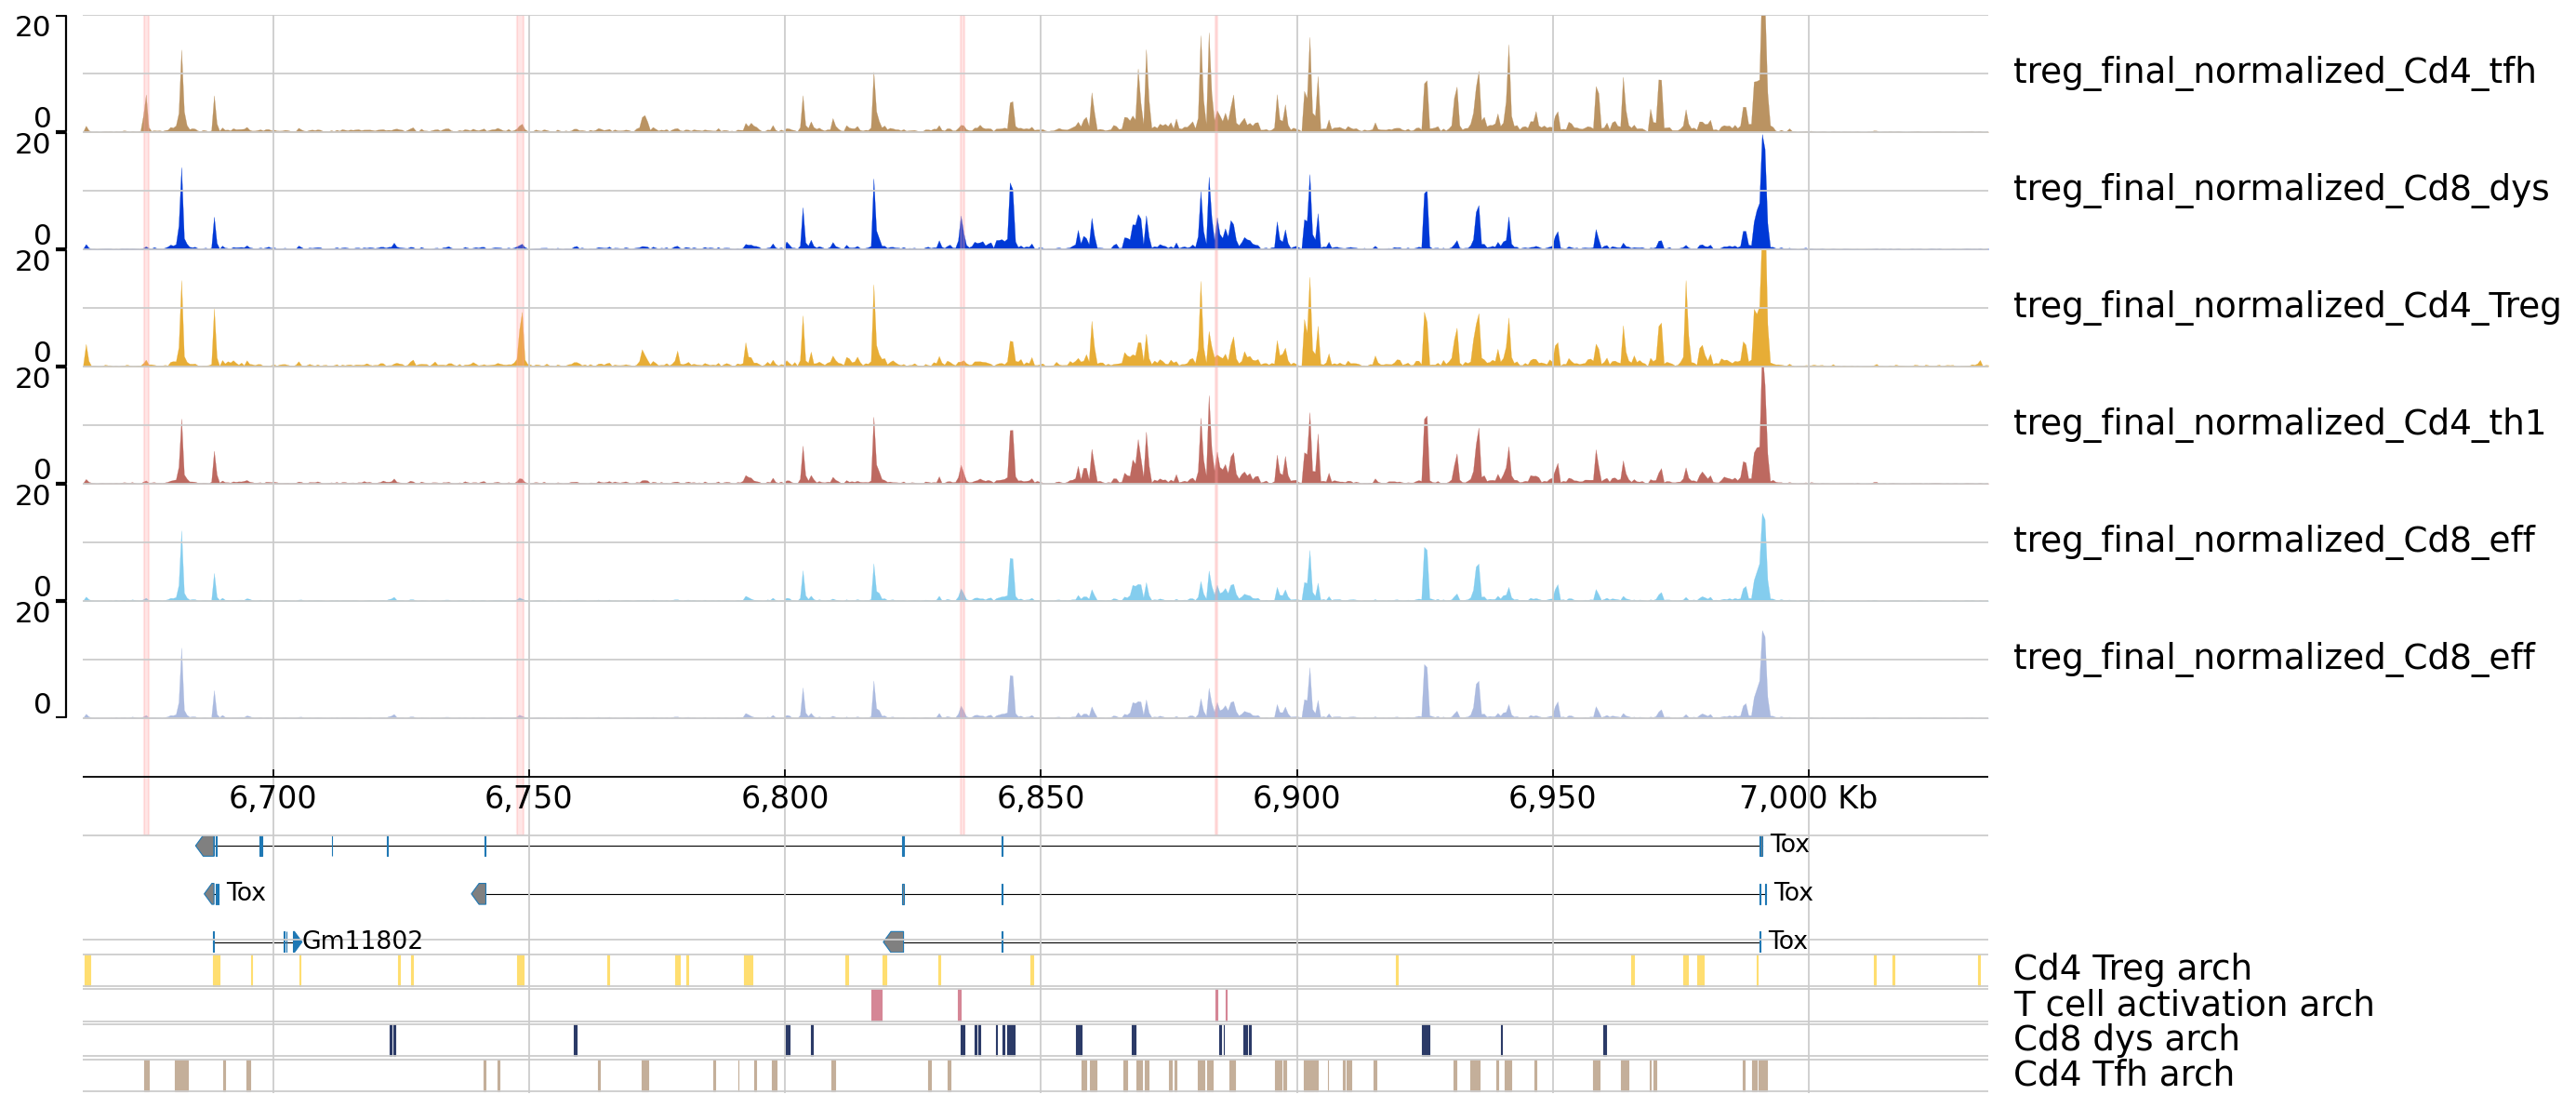

In [25]:
tox_full_plot(min_ = 0, max_ = 20, bigwig_fns = treg_bws, loc = "chr4:6662900-7035000")


In [17]:
tox_full_plot(min_ = 0, max_ = 20, bigwig_fns = treg_bws, loc = "chr4:6662900-7035000", save = 
              "../new_bigwigs_mar2025/plots/tox_full_track.pdf")
